# ResPlan preprocessing pipeline

**Objective**
Prepare ResPlan floorplans up to the room-only, axis-grid-regularized, geometry-clean, narrow-gap-cleaned, and minimum-room-area-filtered representation, while also persisting the final selected preprocessing subset for convex decomposition.

**Source credit**
This workflow uses the upstream `ResPlan` dataset from [m-agour/ResPlan](https://github.com/m-agour/ResPlan). That source data is not created by `ConvexDecomp`; this repository adds the paper-specific preprocessing workflow around it, while cloning the upstream repository locally only to fetch the dataset archive when it is missing.

**Workflow overview**
1. Reuse the local `external/resplan/ResPlan.pkl` when present, otherwise clone the upstream ResPlan repository, extract `ResPlan.zip`, and then load and normalize the raw floorplans.
2. Remove near-duplicate and colinear room vertices on the raw geometry before any concavity counting.
3. Apply a cheap raw concavity preselection before rescaling so obviously irrelevant plans are skipped early, while estimating the metric scale factor from the metadata area and the traced inner-footprint area.
4. Rescale the preselected plans into approximate metric coordinates and inspect the rescaling summary.
5. Estimate wall thickness and offset room polygons into wall space before non-room layers are discarded.
6. Keep only the main room polygons needed for decomposition and split multipart rooms into explicit polygon pieces.
7. Infer architectural horizontal and vertical axes from matching room edges with the shared `convexdecomp.resplan.axes` helpers.
8. Keep boundary axes and only those internal axes that have enough merged support or at least one sufficiently long supporting edge.
9. Reconstruct room polygons on the architectural axis grid by assigning grid cells to the original room instances from the cell centers and simplify the merged cell unions immediately.
10. Close narrow double-wall gaps when two long parallel room edges are separated only by a tiny empty strip and one wall can safely be moved to the other.
11. Remove plans with room parts below `2.0 m^2`, then keep only the final `>=3`-concave subset for convex decomposition.
12. Save the final selected subset to `data/resplan/floorplans_aligned_quantized.pickle` for the decomposition notebook.


### Imports and dataset setup
One cell resolves the project paths, imports the shared preprocessing and axis-inference helpers, forces simple inline plotting for the ResPlan workflow, clones the upstream ResPlan repository into `external/resplan/` when the dataset archive source is missing, extracts `ResPlan.pkl` from `ResPlan.zip`, defines the main constants, and loads the raw subset used in the current run.


In [1]:
# Standard library
import math
import pickle
import sys
from pathlib import Path
from typing import Any, Dict, List, Tuple

# Third-party libraries
from IPython import get_ipython
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import MultiPolygon, Polygon
from shapely.geometry.base import BaseGeometry
from shapely.ops import unary_union

ip = get_ipython()
# ResPlan stays inline so the public notebooks do not depend on frontend-specific backends.
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')

from convexdecomp.notebook_utils import ensure_resplan_dataset, find_project_root
from convexdecomp.resplan.plan_helpers import area, compute_scale_from_meta, normalize_keys
from convexdecomp.resplan.upstream import get_category_colors, plot_plan

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
EXTERNAL_DIR = PROJECT_ROOT / "external"
RESPLAN_VENDOR_DIR = EXTERNAL_DIR / "resplan"
RESPLAN_DATA_DIR = PROJECT_ROOT / "data" / "resplan"

for extra_path in (PROJECT_ROOT, SRC_DIR):
    if str(extra_path) not in sys.path:
        sys.path.insert(0, str(extra_path))


from convexdecomp.core.convexity import concave_polygon_count
from convexdecomp.resplan.axes import (
    infer_floorplan_axes,
    plot_floorplans_with_axes,
    summarize_floorplan_axes,
)
from convexdecomp.resplan.axis_grid import (
    filter_plans_by_min_room_area,
    plot_axis_grid_reconstruction_pairs,
    plot_gap_cleanup_examples,
    reconstruct_floorplans_on_axis_grid,
    select_concave_subset,
)
from convexdecomp.resplan.preprocess import (
    annotate_plans_with_wall_thickness,
    clean_raw_room_vertices,
    clean_room_plan_geometries,
    close_narrow_parallel_gaps,
    count_plan_room_polygons,
    explode_polygon_parts,
    grow_rooms_by_stored_wall_thickness,
    iter_plan_room_polygons,
    offset_rooms_into_walls,
    open_concave_room_polygons,
    plan_room_polygons,
    reduce_to_room_layer_plans,
    rescale_floorplans,
    scaled_room_polygons_above_area,
    split_room_plans,
)
from convexdecomp.resplan.showcase import (
    plot_dropped_preselection_examples,
    plot_floorplans_grid,
    render_showcase_panel,
    select_showcase_ids,
)

# Configuration
FP_COUNT = 50000  # Number of floorplans to process; set to None to use all plans
SEL_IDX = 0  # Index of a floorplan to show more details of
ROOM_KEYS = {"bathroom", "bedroom", "stair", "kitchen", "storage", "living"}
RAW_VERTEX_REL_TOL = 1e-5
RAW_VERTEX_ABS_TOL = 1e-6
MIN_AREA_M2 = 2.0
RAW_PRESELECTION_MIN_CONCAVE_ROOMS = 3
PRESELECTION_DROPPED_PREVIEW_COUNT = 6
MAX_WALL_PART_SAMPLES = 10
MIN_WALL_THICKNESS_M = 0.05
MAX_WALL_THICKNESS_M = 1.0
PRE_OFFSET_OPENING_SCALE = 0.5
PRE_OFFSET_OPENING_MIN_M = 0.05
PRE_OFFSET_OPENING_MAX_M = 0.2
PRE_OFFSET_MAX_AREA_LOSS_RATIO = 0.35
NARROW_GAP_MAX_M = 0.35
NARROW_GAP_MIN_PARALLEL_LENGTH_M = 1.5
NARROW_GAP_MIN_REFERENCE_OVERLAP_RATIO = 0.6
NARROW_GAP_MAX_COMPACTNESS_DROP = 0.08
SHOWCASE_PLAN_IDS = [10171, 13737, 12600]
SHOWCASE_PLAN_COUNT = 1  # One representative walkthrough is enough for the public notebook.
GAP_CLEANUP_PREVIEW_COUNT = 3
RESPLAN_REPO_URL = "https://github.com/m-agour/ResPlan.git"

# Load the raw dataset
CATEGORY_COLORS = get_category_colors()
RESPLAN_PKL = RESPLAN_VENDOR_DIR / "ResPlan.pkl"
ensure_resplan_dataset(RESPLAN_PKL, repo_dir=RESPLAN_VENDOR_DIR, repo_url=RESPLAN_REPO_URL)

with open(RESPLAN_PKL, "rb") as f:
    all_plans = pickle.load(f)

total_plan_count = len(all_plans)
effective_fp_count = total_plan_count if FP_COUNT is None else min(FP_COUNT, total_plan_count)

floorplans_all = [normalize_keys(plan) for plan in all_plans[:effective_fp_count]]
floorplans = floorplans_all
print(
    f"Loaded {len(floorplans_all)} floorplans out of {total_plan_count}. "
    f"Using indices 0..{len(floorplans_all) - 1}."
)


[ResPlan] upstream repo present: /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/ConvexDecomp/external/resplan
[ResPlan] dataset present: /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/ConvexDecomp/external/resplan/ResPlan.pkl
Loaded 17000 floorplans out of 17000. Using indices 0..16999.


### Clean near-duplicate and colinear raw room vertices
Call the shared room-geometry cleanup helper on the raw room polygons before any concavity counting.


In [2]:
floorplans_all_raw = floorplans_all
floorplans_all, raw_vertex_cleanup_stats = clean_raw_room_vertices(
    floorplans_all_raw,
    ROOM_KEYS,
    rel_tol=RAW_VERTEX_REL_TOL,
    abs_tol=RAW_VERTEX_ABS_TOL,
    normalize_plan=normalize_keys,
)
floorplans = floorplans_all

print(
    f"[Raw room vertex cleanup] Room vertices: {raw_vertex_cleanup_stats['before_vertices']} -> "
    f"{raw_vertex_cleanup_stats['after_vertices']} "
    f"(removed {raw_vertex_cleanup_stats['removed_vertices']})"
)
print(
    f"[Raw room vertex cleanup] Room geometries changed: "
    f"{raw_vertex_cleanup_stats['changed_room_geometries']}"
)


[Raw room vertex cleanup] Room vertices: 1058625 -> 1009381 (removed 49244)
[Raw room vertex cleanup] Room geometries changed: 20463


### Preselect plans with many concave rooms before rescaling

**Why a scale factor is needed**
ResPlan floorplans were traced from images, so their raw coordinates are only drawing units and are not directly interpretable as meters. The metadata still records the total plan area, and each plan also has a traced `inner` footprint polygon. Comparing those two areas lets us estimate one isotropic scale factor per plan with `scale = sqrt(metadata_area / traced_inner_area)`, which is enough to convert later area and distance thresholds into approximate metric units.

**Inputs:**
- `floorplans_all` raw normalized floorplans after early room-vertex cleanup
- Shared strict convexity helper `convexdecomp.core.convexity`
- `MIN_AREA_M2=2.0` used only to ignore raw room parts that would be too small after rescaling

**Steps:**
1. Estimate the metric scale factor of each raw plan without rescaling the full geometry yet.
2. Keep only room polygon parts whose scaled area already exceeds `MIN_AREA_M2`, so tiny traced fragments do not affect the early concavity count.
3. Count non-convex room polygons with the shared convexity helper and keep only plans with at least `3` concave rooms.
4. Collect a small balanced preview of dropped plans from the `0`, `1`, and `2` concave-room buckets for quick visual inspection.
5. Store the selected raw plans and their scale factors so only those candidates are rescaled downstream.

**Outputs:**
- `floorplans` reduced to the raw preselected candidate subset
- `preselected_scale_factors`
- `raw_hard_case_count_before`
- A small gallery of dropped low-concavity plans


[Raw concavity preselection] Plans with >=3 concave rooms before preprocessing: 11736 / 17000 (69.0%)
[Raw concavity preselection] Dropped plans with <3 concave rooms: 5264


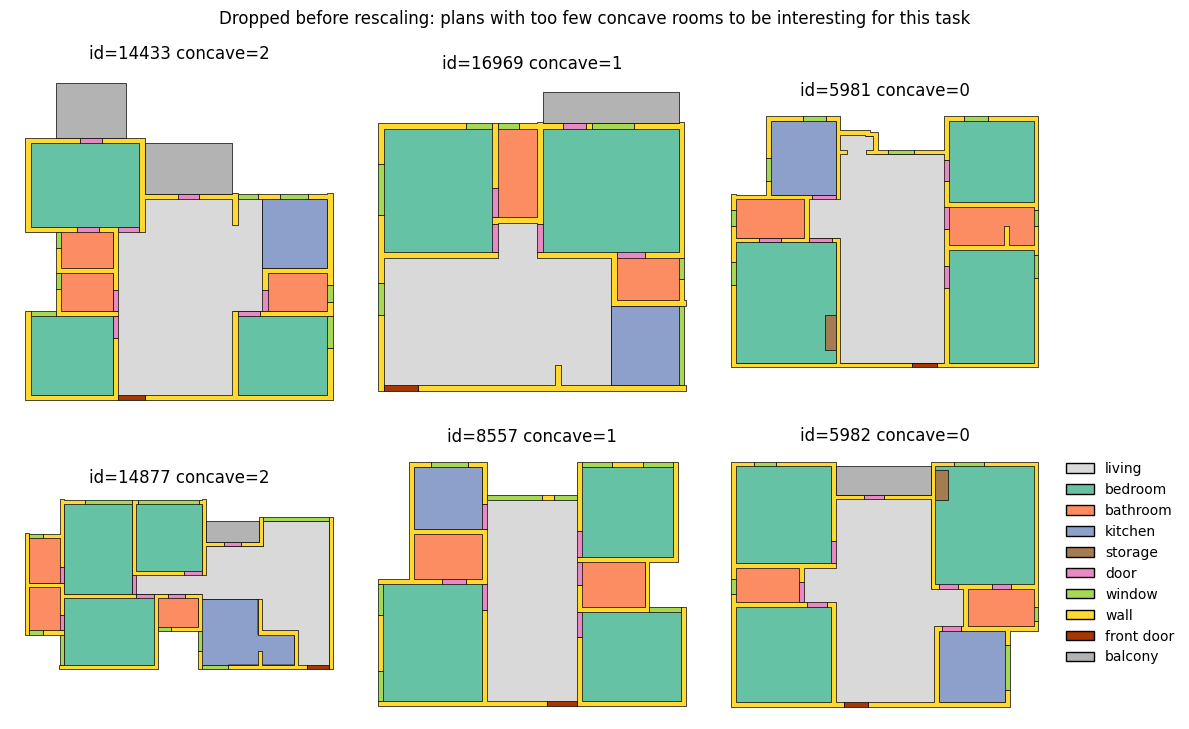

In [3]:
preselected_floorplans = []
preselected_scale_factors = []
dropped_preselection_records = []

for fp in floorplans_all:
    scale_factor = compute_scale_from_meta(fp)
    room_polys = scaled_room_polygons_above_area(fp, ROOM_KEYS, scale_factor, MIN_AREA_M2)
    concave_count = concave_polygon_count(room_polys)

    if concave_count >= RAW_PRESELECTION_MIN_CONCAVE_ROOMS:
        preselected_floorplans.append(fp)
        preselected_scale_factors.append(scale_factor)
    else:
        dropped_preselection_records.append({
            "id": fp.get("id"),
            "concave_count": int(concave_count),
            "plan": fp,
        })

floorplans = preselected_floorplans
raw_hard_case_count_before = len(floorplans)
raw_preselection_pct = 100.0 * raw_hard_case_count_before / len(floorplans_all) if floorplans_all else 0.0

print(
    f"[Raw concavity preselection] Plans with >=3 concave rooms before preprocessing: "
    f"{raw_hard_case_count_before} / {len(floorplans_all)} ({raw_preselection_pct:.1f}%)"
)
print(
    f"[Raw concavity preselection] Dropped plans with <3 concave rooms: "
    f"{len(dropped_preselection_records)}"
)

plot_dropped_preselection_examples(
    dropped_preselection_records,
    max_examples=PRESELECTION_DROPPED_PREVIEW_COUNT,
)


### Rescale the preselected floorplans
Only the preselected plans are rescaled. The same area-derived scale factor is applied uniformly in both coordinate directions, which converts the traced floorplans from arbitrary drawing units into approximate metric coordinates while preserving shape. This makes later thresholds such as room area, wall thickness, and gap width comparable across plans. The summary table reports the factor used for each plan together with the inner-footprint areas before and after rescaling.


In [4]:
rescaled_floorplans, df_summary = rescale_floorplans(floorplans, preselected_scale_factors)
print(f"Rescaled {len(rescaled_floorplans)} preselected floorplans.")
display(df_summary.head())


Rescaled 11736 preselected floorplans.


,plan_idx,plan_id,scale_factor,wall_depth_m
0,0,14926,0.043915,0.225220
1,1,5410,0.047858,0.234108
2,2,1448,0.097909,0.322030
3,3,14035,0.072171,0.252228
4,4,7067,0.042503,0.167060


### Estimate wall thickness, drop non-room layers, clean concave rooms, and then grow rooms
First estimate and store wall thickness on the rescaled plans, then discard walls / windows / doors early, run a conservative shrink-expand on concave room polygons without allowing room splits, and finally grow the cleaned rooms by half of the stored wall thickness.


In [5]:
rescaled_floorplans, wall_thickness_summary_df = annotate_plans_with_wall_thickness(
    rescaled_floorplans,
    normalize_plan=normalize_keys,
    max_wall_parts=MAX_WALL_PART_SAMPLES,
    min_thickness_m=MIN_WALL_THICKNESS_M,
    max_thickness_m=MAX_WALL_THICKNESS_M,
)

floorplans_rooms_pre_offset = reduce_to_room_layer_plans(
    rescaled_floorplans,
    ROOM_KEYS,
    keep_keys=("id", "inner", "wall_thickness_m", "wall_thickness_source"),
)

floorplans_rooms_pre_offset, pre_offset_opening_stats = open_concave_room_polygons(
    floorplans_rooms_pre_offset,
    ROOM_KEYS,
    normalize_plan=normalize_keys,
    opening_tol_scale=PRE_OFFSET_OPENING_SCALE,
    min_opening_tol_m=PRE_OFFSET_OPENING_MIN_M,
    max_opening_tol_m=PRE_OFFSET_OPENING_MAX_M,
    max_area_loss_ratio=PRE_OFFSET_MAX_AREA_LOSS_RATIO,
)

room_offset_floorplans, room_offset_summary_df, wall_offset_fallback_count = grow_rooms_by_stored_wall_thickness(
    floorplans_rooms_pre_offset,
    ROOM_KEYS,
    normalize_plan=normalize_keys,
)

if not wall_thickness_summary_df.empty:
    valid_thickness = wall_thickness_summary_df[wall_thickness_summary_df["wall_thickness_m"] > 0]["wall_thickness_m"]
    if not valid_thickness.empty:
        print(
            f"Estimated wall thickness for {len(valid_thickness)} / {len(wall_thickness_summary_df)} plans "
            f"(median {valid_thickness.median():.3f} m, mean {valid_thickness.mean():.3f} m)."
        )
    else:
        print("No usable wall-thickness estimates found.")

print(
    f"[Pre-offset concave cleanup] Changed {pre_offset_opening_stats['plans_changed']} / {len(floorplans_rooms_pre_offset)} plans "
    f"and {pre_offset_opening_stats['changed_room_geometries']} room polygons "
    f"(removed {pre_offset_opening_stats['total_area_removed_m2']:.2f} m^2)."
)
print(
    f"[Pre-offset concave cleanup] Opening tolerance = clamp("
    f"{pre_offset_opening_stats['opening_tol_scale']:.2f} * wall_thickness, "
    f"{pre_offset_opening_stats['min_opening_tol_m']:.2f}, "
    f"{pre_offset_opening_stats['max_opening_tol_m']:.2f}) m; "
    f"max area loss ratio = {100.0 * pre_offset_opening_stats['max_area_loss_ratio']:.0f}%."
)
if pre_offset_opening_stats["rejected_split"] or pre_offset_opening_stats["rejected_area_loss"]:
    print(
        f"[Pre-offset concave cleanup] Rejected split candidates: "
        f"{pre_offset_opening_stats['rejected_split']}; "
        f"rejected high-area-loss candidates: {pre_offset_opening_stats['rejected_area_loss']}."
    )
if wall_offset_fallback_count:
    print(f"[Wall offset] Plans kept unchanged after topology fallback: {wall_offset_fallback_count}")

print(f"Applied collision-aware half-wall room offset to {len(room_offset_floorplans)} plans.")
display(room_offset_summary_df.head())


/Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/.venv/lib/python3.12/site-packages/shapely/constructive.py:1353: RuntimeWarning: divide by zero encountered in oriented_envelope
  return lib.oriented_envelope(geometry, **kwargs)
/Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/.venv/lib/python3.12/site-packages/shapely/constructive.py:1353: RuntimeWarning: invalid value encountered in oriented_envelope
  return lib.oriented_envelope(geometry, **kwargs)


Estimated wall thickness for 10243 / 11736 plans (median 0.401 m, mean 0.459 m).
[Pre-offset concave cleanup] Changed 9278 / 11736 plans and 17918 room polygons (removed 1612.20 m^2).
[Pre-offset concave cleanup] Opening tolerance = clamp(0.50 * wall_thickness, 0.05, 0.20) m; max area loss ratio = 35%.
[Pre-offset concave cleanup] Rejected split candidates: 66; rejected high-area-loss candidates: 2.
Applied collision-aware half-wall room offset to 11736 plans.


,id,wall_thickness_m,wall_thickness_source,room_area_before_m2,room_area_after_m2,room_growth_area_m2,offset_topology_fallback
0,14926,0.874257,sampled_walls,81.401083,81.420601,0.019519,False
1,5410,0.234108,sampled_walls,88.284079,90.984740,2.700661,False
2,1448,0.000000,missing,239.228625,239.228625,0.000000,False
3,14035,0.273247,sampled_walls,112.986479,114.909000,1.922521,False
4,7067,0.308418,sampled_walls,60.490685,61.040912,0.550227,False


## Keep room polygons


### Keep only the room polygons and split multipart rooms
Drop the stored helper fields after the growth step so the downstream axis-inference pipeline works on room geometry only, then explode multipart room geometries into explicit polygon parts and discard parts smaller than `MIN_AREA_M2`.


In [6]:
floorplans_rooms = reduce_to_room_layer_plans(room_offset_floorplans, ROOM_KEYS, keep_keys=("id",))
floorplans_rooms_split = split_room_plans(floorplans_rooms, ROOM_KEYS, min_area_m2=MIN_AREA_M2)

print(f"Built {len(floorplans_rooms_split)} reduced room plans before architectural-axis inference.")


Built 11736 reduced room plans before architectural-axis inference.


### Visualize the reduced split room plans
Plot the first few reduced candidate plans after the multipart rooms have been split into explicit polygon pieces.


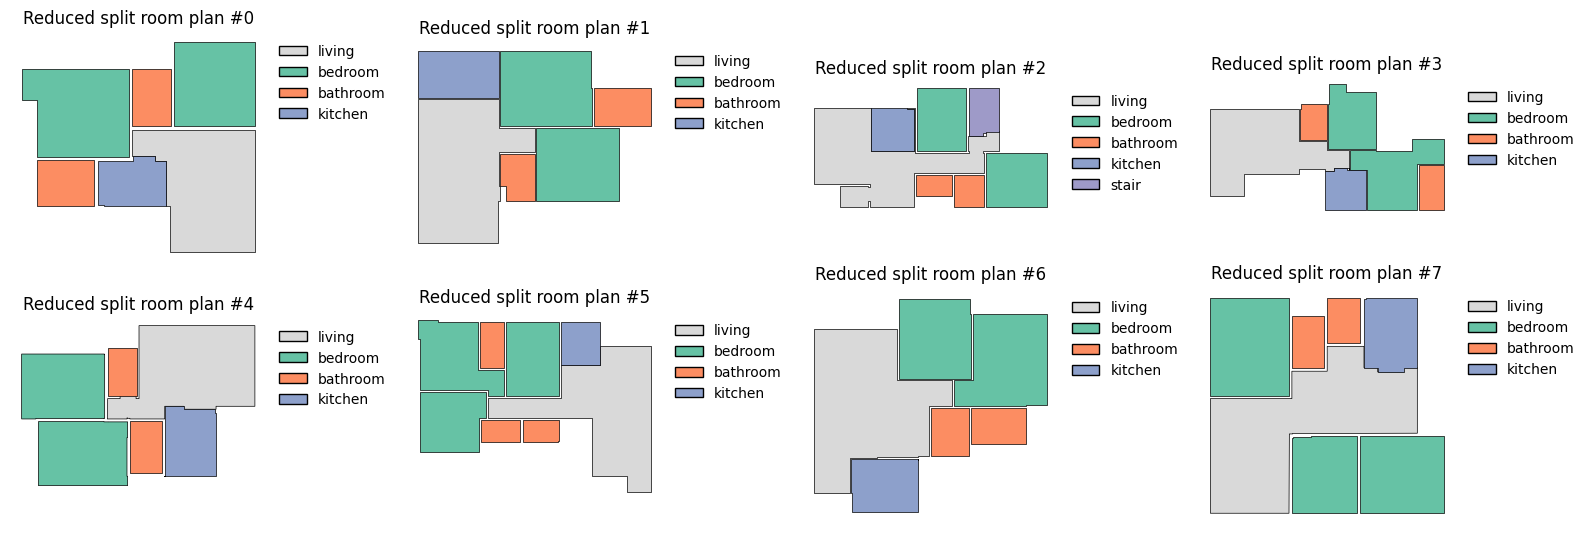

In [7]:
plot_floorplans_grid(floorplans_rooms_split, ncols=4, nrows=2, title_prefix="Reduced split room plan")


## Regularize rooms on an architectural axis grid


### Infer architectural axes from matching room edges

**Inputs:**
- `floorplans_rooms_split` with explicit room polygon parts
- Shared `convexdecomp.resplan.axes` helpers for edge clustering, support filtering, summaries, and overlay plots
- Axis tolerances `LINE_ANGLE_TOL_DEG=2.0`, `LINE_OFFSET_TOL_M=0.5`
- Axis-support filters `MIN_AXIS_SUPPORT_UNION_M=1.9`, `MIN_AXIS_SUPPORT_LONGEST_M=0.75`, `MIN_AXIS_MEMBER_LEN_M=1.5`

**Steps:**
1. Call the shared axis-inference helpers on the split room plans.
2. Detect already orthogonal plans and lock their line families to horizontal and vertical only.
3. Cluster edges into architectural-axis bins without forcing a fixed number of bins.
4. Keep the outer boundary axes and filter internal axes by merged support and long-edge evidence.
5. Plot the first few room-only plans with the inferred architectural axes overlaid.
6. Summarize how many axes survive per plan after filtering.

**Outputs:**
- `floorplan_axes_data`
- `floorplan_axes_by_id`
- `axis_summary_df`


[Architectural axes] Orthogonal family-lock applied to 11228 / 11736 plans.
[Architectural axes] Mean kept axes per plan: 15.49 (vertical 7.38, horizontal 6.90)


,id,orthogonal_only,axis_count_before,axis_count_after,vertical_axes_after,horizontal_axes_after
0,14926,True,15,12,6,6
1,5410,True,15,13,6,7
2,1448,True,20,17,9,8
3,14035,True,20,18,9,9
4,7067,True,16,12,7,5


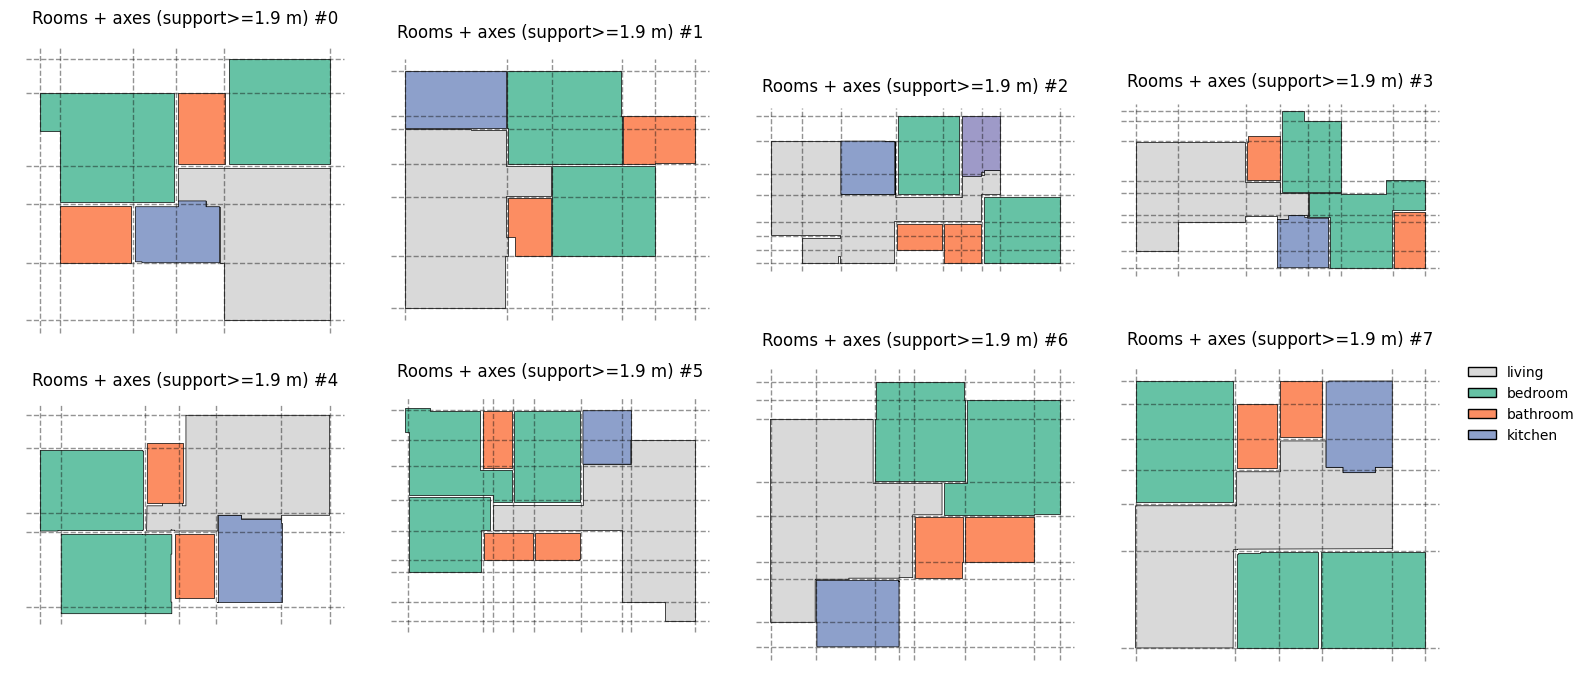

In [8]:
### Infer architectural axes from matching room edges + visualize

LINE_ANGLE_TOL_DEG = 2.0
LINE_OFFSET_TOL_M = 0.5
ORTHOGONAL_PLAN_TOL_DEG = 5.0
ORTHOGONAL_MIN_EDGE_LEN_M = 0.15
MIN_AXIS_SUPPORT_UNION_M = 1.9
MIN_AXIS_SUPPORT_LONGEST_M = 0.75
MIN_AXIS_MEMBER_LEN_M = 1.5
AXIS_PREVIEW_COUNT = 8

floorplan_axes_data = infer_floorplan_axes(
    floorplans_rooms_split,
    ROOM_KEYS,
    line_angle_tol_deg=LINE_ANGLE_TOL_DEG,
    line_offset_tol_m=LINE_OFFSET_TOL_M,
    orthogonal_plan_tol_deg=ORTHOGONAL_PLAN_TOL_DEG,
    orthogonal_min_edge_len_m=ORTHOGONAL_MIN_EDGE_LEN_M,
    min_axis_support_union_m=MIN_AXIS_SUPPORT_UNION_M,
    min_axis_support_longest_m=MIN_AXIS_SUPPORT_LONGEST_M,
    min_axis_member_len_m=MIN_AXIS_MEMBER_LEN_M,
)
floorplan_axes_by_id = {item["id"]: item for item in floorplan_axes_data}
axis_summary_df = summarize_floorplan_axes(floorplan_axes_data)

orthogonal_plan_count = int(axis_summary_df["orthogonal_only"].sum()) if not axis_summary_df.empty else 0
print(f"[Architectural axes] Orthogonal family-lock applied to {orthogonal_plan_count} / {len(floorplan_axes_data)} plans.")
if not axis_summary_df.empty:
    print(
        f"[Architectural axes] Mean kept axes per plan: {axis_summary_df['axis_count_after'].mean():.2f} "
        f"(vertical {axis_summary_df['vertical_axes_after'].mean():.2f}, horizontal {axis_summary_df['horizontal_axes_after'].mean():.2f})"
    )

display(axis_summary_df.head())
plot_floorplans_with_axes(
    floorplans_rooms_split[: min(AXIS_PREVIEW_COUNT, len(floorplans_rooms_split))],
    ROOM_KEYS,
    floorplan_axes_by_id,
    ncols=4,
    title_prefix=f"Rooms + axes (support>={MIN_AXIS_SUPPORT_UNION_M:.1f} m)",
)


### Reconstruct rooms on the architectural axis grid

**Inputs:**
- `floorplans_rooms_split` with explicit room polygon parts
- `floorplan_axes_by_id` with filtered architectural axes per plan
- Shared `convexdecomp.resplan.axis_grid` helpers for axis-grid reconstruction, metrics, and plots
- Shared room-geometry cleanup helper for immediate simplification of merged cell unions

**Steps:**
1. Build the rectangular axis grid from the kept horizontal and vertical architectural axes.
2. Keep only grid cells whose centers lie inside the original room footprint.
3. Assign each kept cell to the original room instance that contains its center, with overlap fallback only when the midpoint is ambiguous.
4. Merge the assigned cells back into room polygons while preserving separate same-label room instances.
5. Simplify the reconstructed polygons immediately so straight grid runs do not keep one vertex per filled cell boundary.
6. Attach plan graphs, summarize the reconstruction error, and plot paired examples of the original room plan with axes and the cleaned axis-grid room plan.

**Outputs:**
- `floorplans_rooms_axis_grid`
- `axis_grid_metrics_by_id`
- `axis_grid_reconstruction_summary_df`


[Axis-grid reconstruction] Reconstructed 11736 room-only plans on the inferred axis grid.
[Axis-grid reconstruction] Mean |ΔA|=11.92 m^2, mean Σsym=14.99 m^2
[Axis-grid reconstruction] Redundant vertices removed immediately after cell union: 780187 -> 478195 (removed 301992)


,id,x_axis_count,y_axis_count,midpoint_cells,overlap_cells,total_abs_area_error_m2,total_label_symdiff_m2
0,14926,6,6,15,0,4.357384,5.809193
1,5410,6,7,22,0,2.315004,2.389532
2,1448,9,8,47,0,10.370979,14.202965
3,14035,9,9,43,0,3.047028,6.908753
4,7067,7,5,18,0,2.376661,8.465881


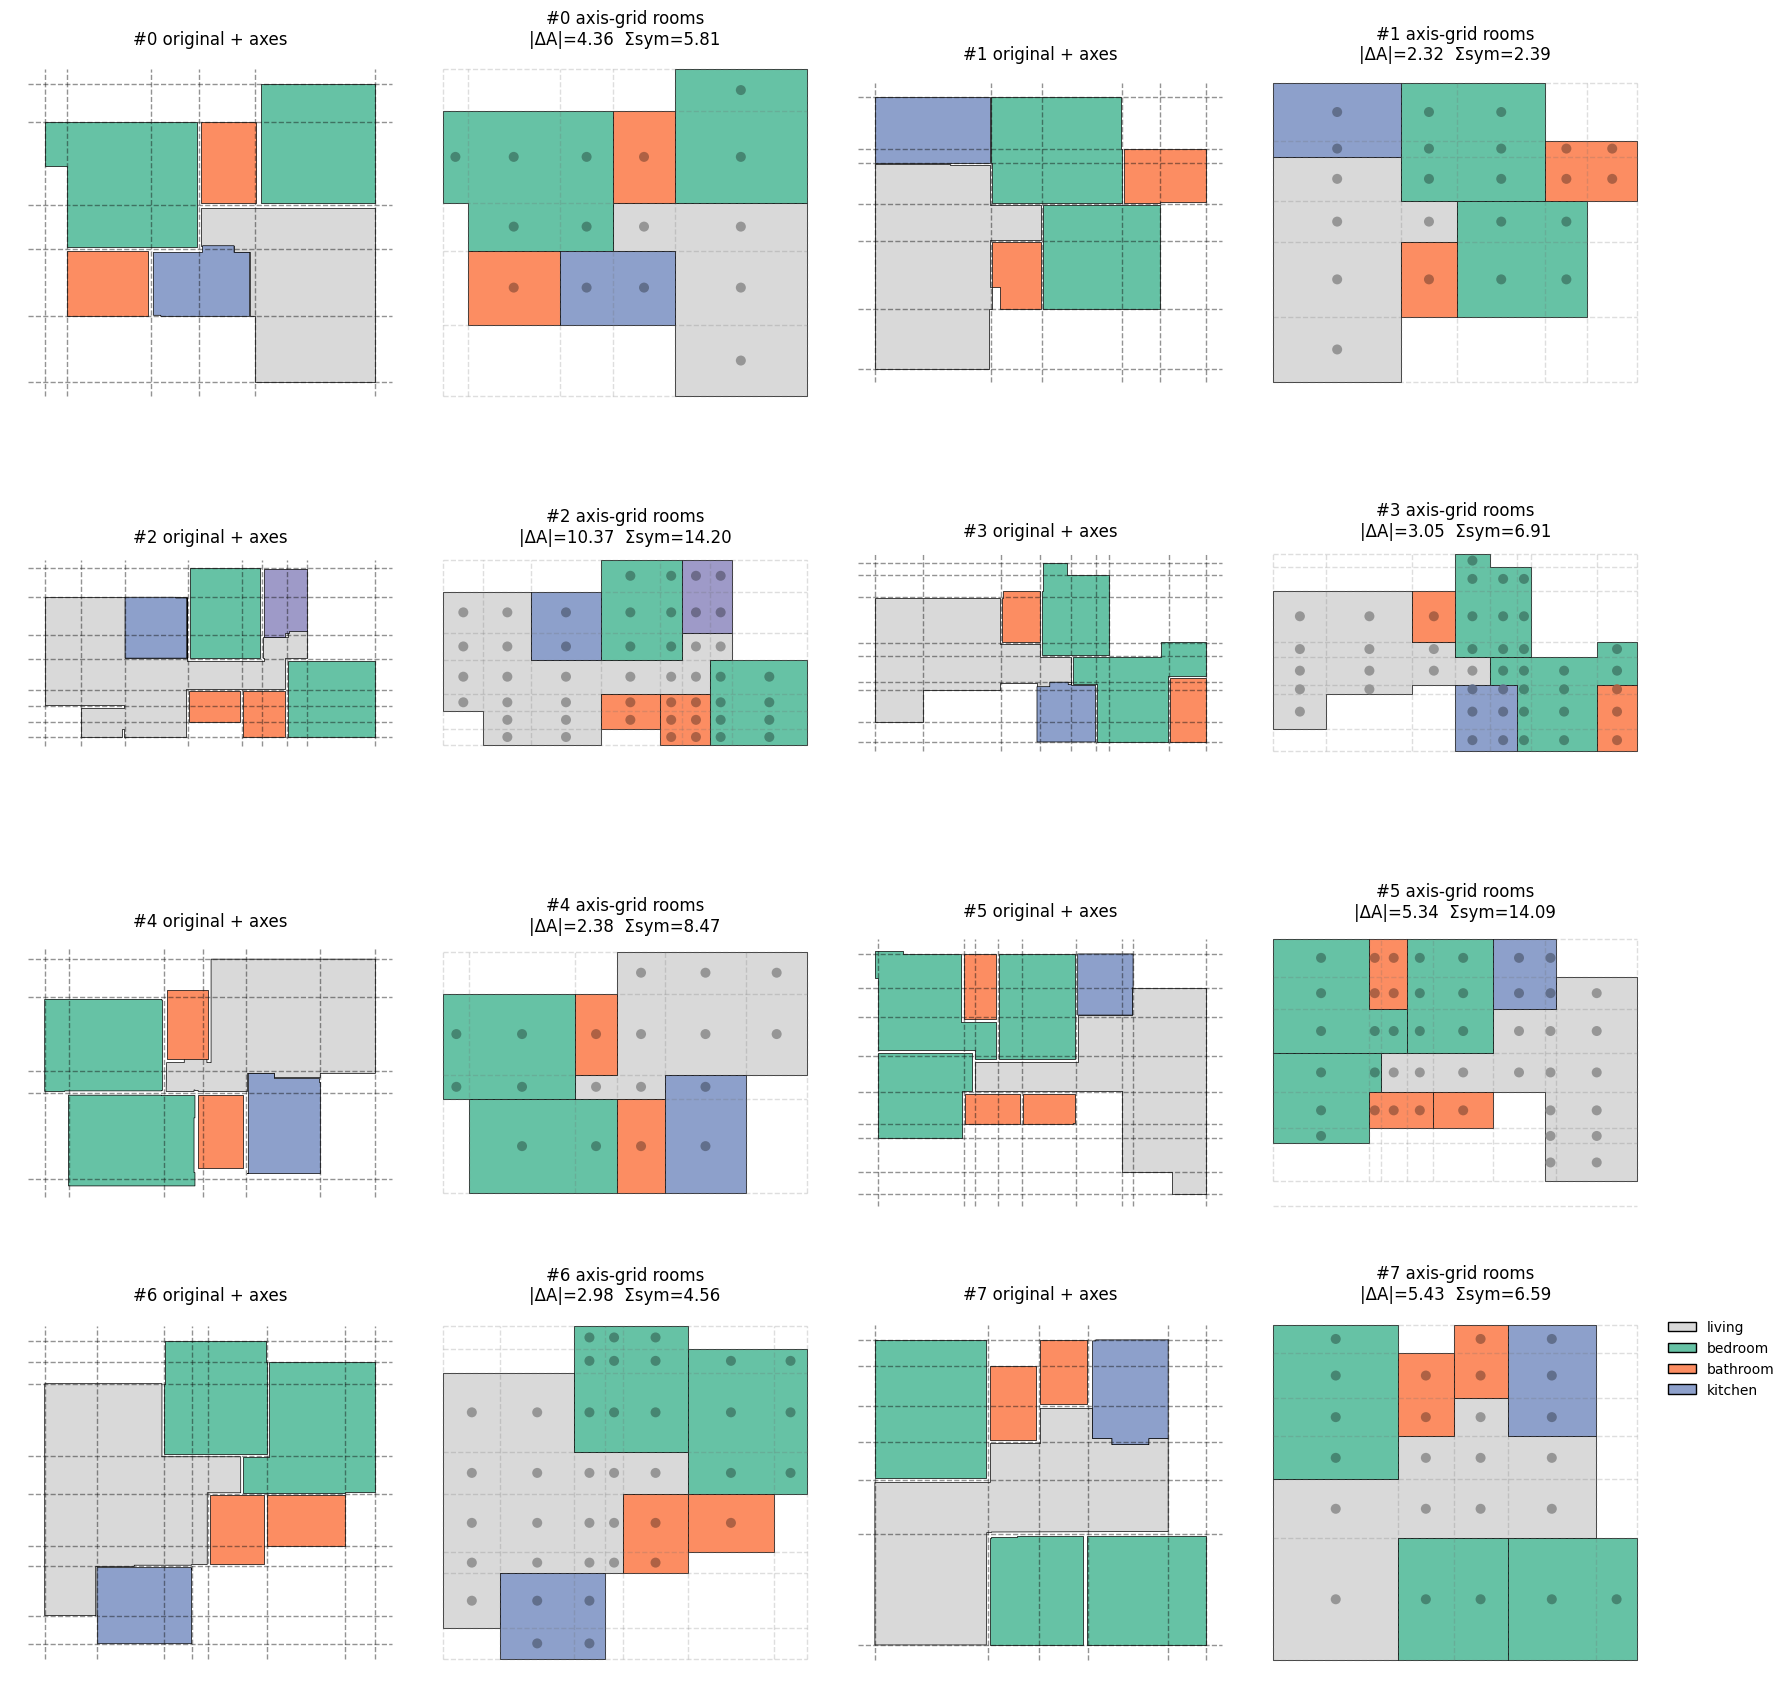

In [9]:
### Reconstruct rooms on the architectural axis grid + visualize

AXIS_GRID_PREVIEW_COUNT = 8

floorplans_rooms_axis_grid, axis_grid_metrics_by_id, axis_grid_reconstruction_summary_df = reconstruct_floorplans_on_axis_grid(
    floorplans_rooms_split,
    floorplan_axes_by_id,
    ROOM_KEYS,
)

floorplans_rooms_axis_grid, geometry_cleanup_stats = clean_room_plan_geometries(
    floorplans_rooms_axis_grid,
    ROOM_KEYS,
    simplify_tol=1e-9,
    normalize_plan=normalize_keys,
)

print(f"[Axis-grid reconstruction] Reconstructed {len(floorplans_rooms_axis_grid)} room-only plans on the inferred axis grid.")
if not axis_grid_reconstruction_summary_df.empty:
    print(
        f"[Axis-grid reconstruction] Mean |ΔA|={axis_grid_reconstruction_summary_df['total_abs_area_error_m2'].mean():.2f} m^2, "
        f"mean Σsym={axis_grid_reconstruction_summary_df['total_label_symdiff_m2'].mean():.2f} m^2"
    )
print(
    f"[Axis-grid reconstruction] Redundant vertices removed immediately after cell union: "
    f"{geometry_cleanup_stats['before_vertices']} -> {geometry_cleanup_stats['after_vertices']} "
    f"(removed {geometry_cleanup_stats['removed_vertices']})"
)
if geometry_cleanup_stats['degenerate_rooms_removed']:
    print(
        f"[Axis-grid reconstruction] Degenerate reconstructed room parts removed: "
        f"{geometry_cleanup_stats['degenerate_rooms_removed']}"
    )

display(axis_grid_reconstruction_summary_df.head())
plot_axis_grid_reconstruction_pairs(
    floorplans_rooms_split,
    floorplans_rooms_axis_grid,
    floorplan_axes_by_id,
    axis_grid_metrics_by_id,
    ROOM_KEYS,
    preview_count=AXIS_GRID_PREVIEW_COUNT,
)


### Close narrow parallel double-wall gaps

**Inputs:**
- `floorplans_rooms_axis_grid` immediately after axis-grid reconstruction
- `floorplans_rooms_split` as the reference room partition before reconstruction
- Narrow-gap thresholds `NARROW_GAP_MAX_M=0.35` and `NARROW_GAP_MIN_PARALLEL_LENGTH_M=1.5`

**Steps:**
1. Detect only tiny empty strips that lie between two parallel room edges with enough shared length.
2. Use the pre-grid room partition as a reference so exterior empty space is not mistaken for a double wall.
3. Test moving either wall to the other one, reject moves that would create overlaps, and keep the smaller relative room change if both directions are valid.
4. Rebuild plan graphs, run a light geometric cleanup again, and plot a small before/after gallery of changed plans.

**Outputs:**
- `axis_grid_showcase_before_gap_cleanup`
- `floorplans_rooms_axis_grid` after narrow-gap cleanup
- `gap_cleanup_stats`
- `gap_cleanup_examples`


[Narrow-gap cleanup] Changed 9 / 11736 plans by closing 10 narrow gap(s).
[Narrow-gap cleanup] Thresholds: gap <= 0.35 m, parallel support >= 1.50 m, reference overlap >= 60%, compactness drop <= 0.08, total absorbed area = 9.42 m^2.
[Narrow-gap cleanup] Immediate geometry cleanup after wall moves: 478202 -> 478187 (removed 15).


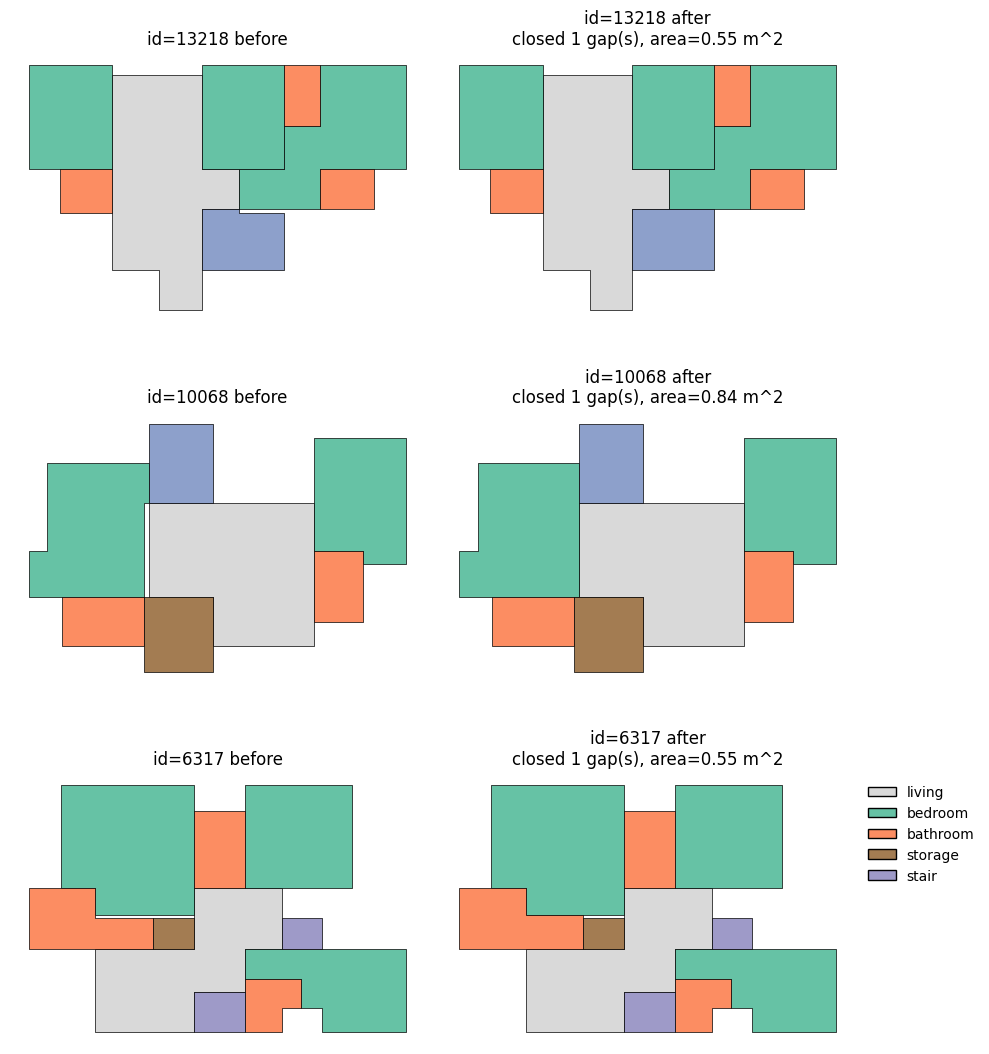

In [10]:
axis_grid_showcase_before_gap_cleanup = {
    plan.get("id"): plan
    for plan in floorplans_rooms_axis_grid
}

floorplans_rooms_axis_grid, gap_cleanup_stats, gap_cleanup_examples = close_narrow_parallel_gaps(
    floorplans_rooms_axis_grid,
    floorplans_rooms_split,
    ROOM_KEYS,
    max_gap_m=NARROW_GAP_MAX_M,
    min_parallel_length_m=NARROW_GAP_MIN_PARALLEL_LENGTH_M,
    min_reference_overlap_ratio=NARROW_GAP_MIN_REFERENCE_OVERLAP_RATIO,
    max_compactness_drop=NARROW_GAP_MAX_COMPACTNESS_DROP,
    normalize_plan=normalize_keys,
    max_examples=GAP_CLEANUP_PREVIEW_COUNT,
)

floorplans_rooms_axis_grid, gap_cleanup_geometry_stats = clean_room_plan_geometries(
    floorplans_rooms_axis_grid,
    ROOM_KEYS,
    simplify_tol=1e-9,
    normalize_plan=normalize_keys,
)

print(
    f"[Narrow-gap cleanup] Changed {gap_cleanup_stats['plans_changed']} / {len(floorplans_rooms_axis_grid)} plans "
    f"by closing {gap_cleanup_stats['gaps_closed']} narrow gap(s)."
)
print(
    f"[Narrow-gap cleanup] Thresholds: gap <= {gap_cleanup_stats['max_gap_m']:.2f} m, "
    f"parallel support >= {gap_cleanup_stats['min_parallel_length_m']:.2f} m, "
    f"reference overlap >= {100.0 * gap_cleanup_stats['min_reference_overlap_ratio']:.0f}%, "
    f"compactness drop <= {gap_cleanup_stats['max_compactness_drop']:.2f}, "
    f"total absorbed area = {gap_cleanup_stats['total_gap_area_m2']:.2f} m^2."
)
if gap_cleanup_geometry_stats["removed_vertices"]:
    print(
        f"[Narrow-gap cleanup] Immediate geometry cleanup after wall moves: "
        f"{gap_cleanup_geometry_stats['before_vertices']} -> {gap_cleanup_geometry_stats['after_vertices']} "
        f"(removed {gap_cleanup_geometry_stats['removed_vertices']})."
    )
plot_gap_cleanup_examples(gap_cleanup_examples, max_examples=GAP_CLEANUP_PREVIEW_COUNT)


### Filter plans below the minimum room area before saving
Keep only plans whose cleaned axis-grid room polygons are all at least `MIN_AREA_M2`, and discard the rest immediately. The area check is handled by the shared `convexdecomp.resplan.axis_grid` helper so the notebook only orchestrates the filter and reports the drop count.


In [11]:
floorplans_rooms_axis_grid, small_room_plan_ids_preprocessing = filter_plans_by_min_room_area(
    floorplans_rooms_axis_grid,
    ROOM_KEYS,
    MIN_AREA_M2,
)
print(
    f"[Preprocessing min-area filter] Discarded plans with rooms below {MIN_AREA_M2:.1f} m^2: "
    f"{len(small_room_plan_ids_preprocessing)}"
)
print(f"[Preprocessing min-area filter] Remaining plans: {len(floorplans_rooms_axis_grid)}")


[Preprocessing min-area filter] Discarded plans with rooms below 2.0 m^2: 862
[Preprocessing min-area filter] Remaining plans: 10874


### Select the final axis-grid concave subset for convex decomposition
The public preprocessing pipeline does not keep every valid floorplan. It intentionally keeps only the more challenging cases with at least `3` concave rooms, because those are the examples where the downstream convex decomposition problem is genuinely non-trivial. This focuses the released working set on more complex plans instead of spending most of the benchmark on already easy layouts.


In [12]:
floorplans_rooms_axis_grid_all = floorplans_rooms_axis_grid
floorplans_rooms_axis_grid, concave_room_counts_final = select_concave_subset(
    floorplans_rooms_axis_grid_all,
    ROOM_KEYS,
    min_concave_rooms=RAW_PRESELECTION_MIN_CONCAVE_ROOMS,
)

current_hard_case_count = len(floorplans_rooms_axis_grid)
final_selected_pct = (
    100.0 * current_hard_case_count / len(floorplans_rooms_axis_grid_all)
    if floorplans_rooms_axis_grid_all else 0.0
)
retained_hard_case_pct = (
    100.0 * current_hard_case_count / raw_hard_case_count_before
    if raw_hard_case_count_before else 0.0
)

print("=== Concave-room reduction through preprocessing ===")
print(f"Plans with >=3 concave rooms before preprocessing: {raw_hard_case_count_before}")
print(f"Plans with >=3 concave rooms after preprocessing:  {current_hard_case_count}")
print(
    f"Final retained subset: {current_hard_case_count} / {len(floorplans_rooms_axis_grid_all)} "
    f"preprocessed plans ({final_selected_pct:.1f}%), retaining {retained_hard_case_pct:.1f}% of the original hard cases."
)


=== Concave-room reduction through preprocessing ===
Plans with >=3 concave rooms before preprocessing: 11736
Plans with >=3 concave rooms after preprocessing:  2935
Final retained subset: 2935 / 10874 preprocessed plans (27.0%), retaining 25.0% of the original hard cases.


### Save the final selected preprocessing output

**Inputs:** `floorplans_rooms_axis_grid` after the full preprocessing pipeline and the final `>= 3 concave rooms` selection

**Steps:**
1. Remove any previous final preprocessing artifact at the same path.
2. Persist only the fully preprocessed `>= 3 concave rooms` subset so the convex decomposition notebook can load the exact working dataset directly.

**Outputs:** `data/resplan/floorplans_aligned_quantized.pickle`


In [13]:
PREPROCESSED_OUTPUT_PATH = RESPLAN_DATA_DIR / "floorplans_aligned_quantized.pickle"
PREPROCESSED_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

if PREPROCESSED_OUTPUT_PATH.exists():
    PREPROCESSED_OUTPUT_PATH.unlink()

with open(PREPROCESSED_OUTPUT_PATH, "wb") as f:
    pickle.dump(floorplans_rooms_axis_grid, f)

print(f"Saved {len(floorplans_rooms_axis_grid)} preprocessed axis-grid floorplans to {PREPROCESSED_OUTPUT_PATH}")


Saved 2935 preprocessed axis-grid floorplans to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/ConvexDecomp/data/resplan/floorplans_aligned_quantized.pickle


## Showcase pipeline panel

This section renders one representative floorplan from the final selected subset directly in the notebook.
It prioritizes the configured showcase id first and falls back to the first available final-selected plan when that id is absent.
The walkthrough keeps the main preprocessing stages visible, including the room-only view before wall offset and the axis-grid stages after axis inference.


,step,room_polygons,vertices,total_room_area_m2,concave_rooms,vertical_axes,horizontal_axes
0,Raw,10,90,40466.028217,5,NaN,NaN
1,Raw vertex-cleaned,10,85,40466.028548,5,NaN,NaN
2,Rescaled,10,85,175.061041,5,NaN,NaN
3,Rooms-only before wall-offset,10,85,175.061041,5,NaN,NaN
4,Wall-offset,10,128,180.138196,8,NaN,NaN
5,Rooms-only,10,128,180.138196,8,NaN,NaN
6,Architectural axes,10,128,180.138196,8,12.0,10.0
7,Axis-grid rooms,10,62,184.600319,4,NaN,NaN
8,Gap-closed axis-grid rooms,10,62,184.600319,4,NaN,NaN
9,Final selected rooms,10,62,184.600319,4,NaN,NaN


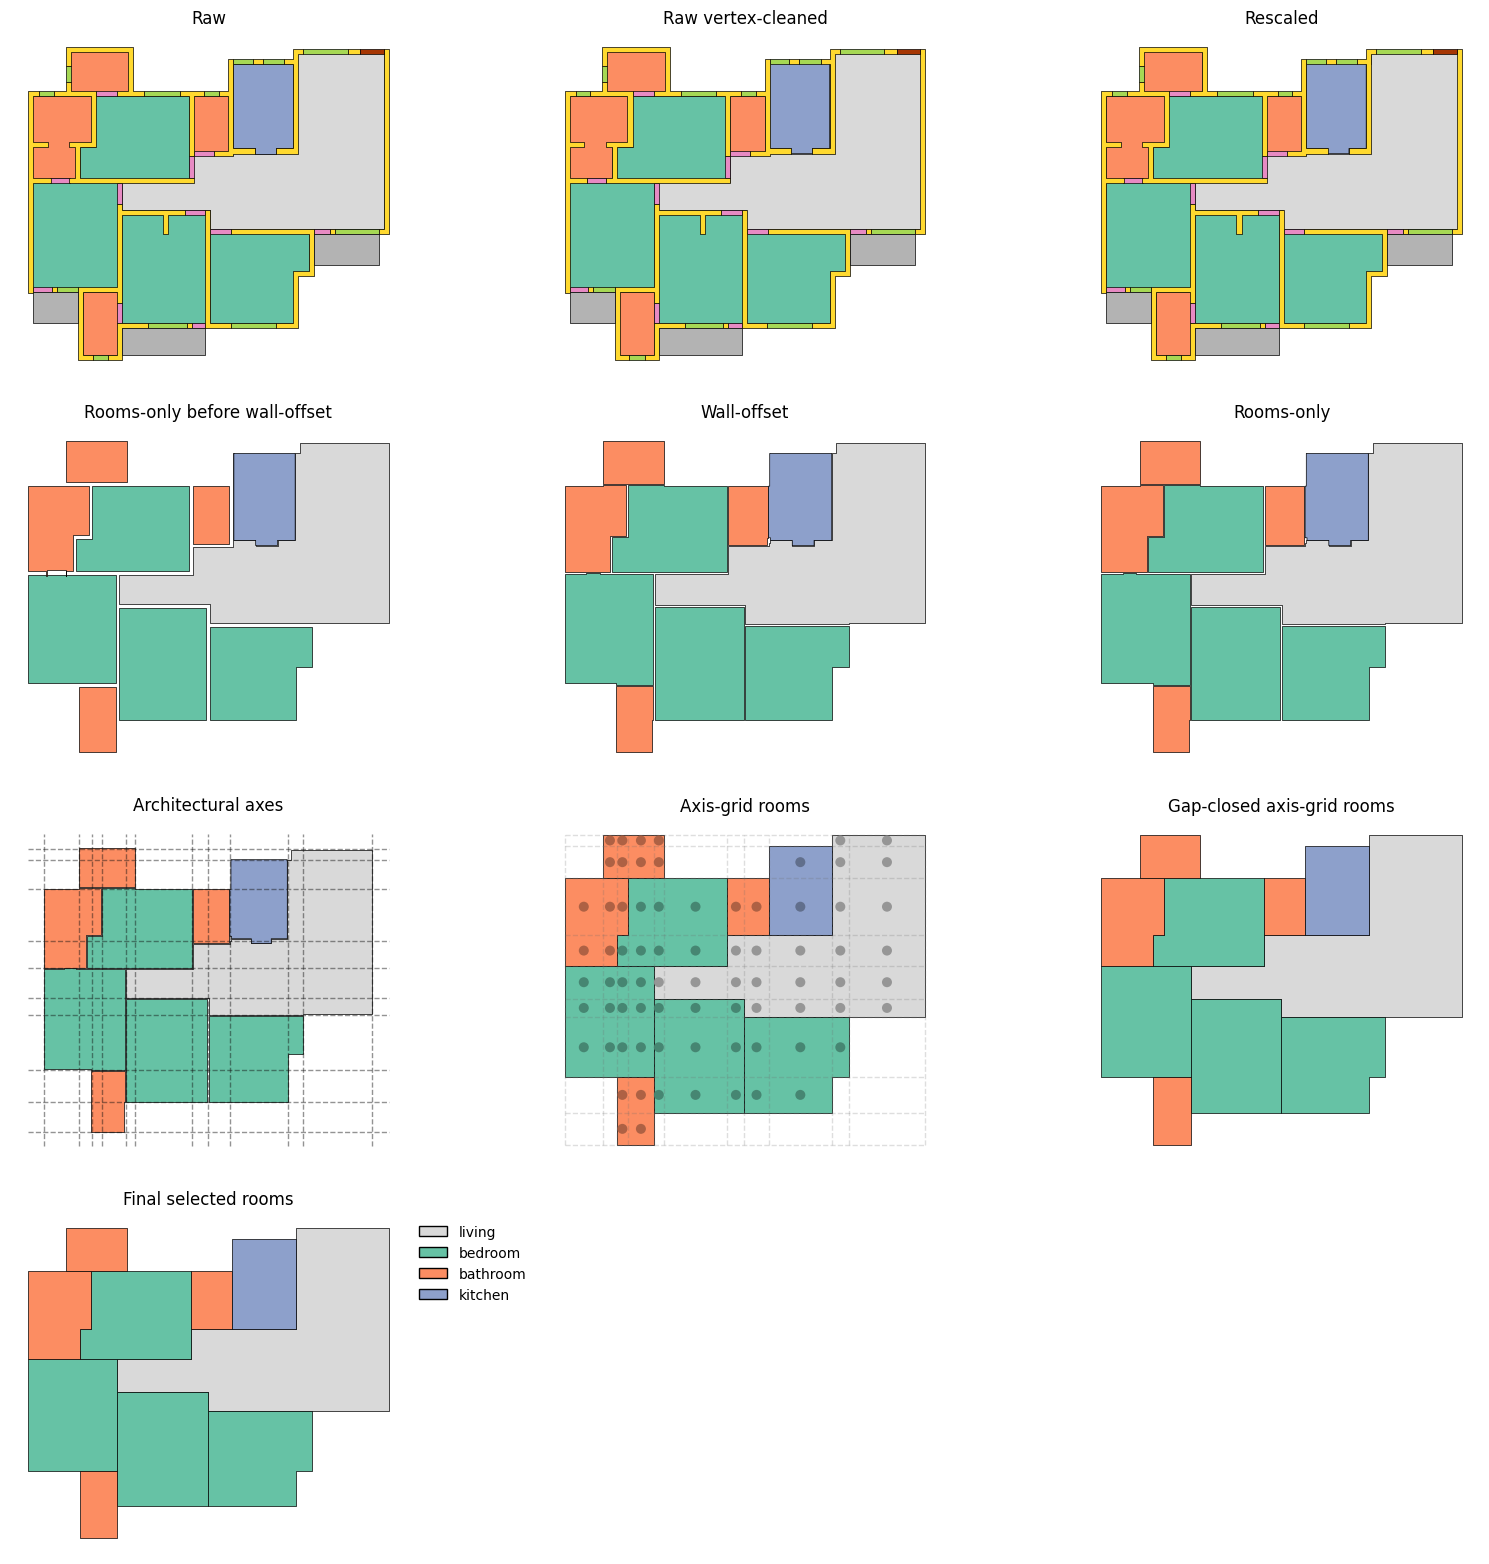

In [14]:
showcase_ids = select_showcase_ids(
    floorplans_rooms_axis_grid,
    SHOWCASE_PLAN_IDS,
    count=max(0, int(SHOWCASE_PLAN_COUNT)),
)

render_showcase_panel(
    showcase_ids=showcase_ids,
    room_keys=ROOM_KEYS,
    floorplans_all_raw=floorplans_all_raw,
    floorplans_all=floorplans_all,
    rescaled_floorplans=rescaled_floorplans,
    room_offset_floorplans=room_offset_floorplans,
    floorplans_rooms=floorplans_rooms,
    floorplans_rooms_split=floorplans_rooms_split,
    axis_grid_showcase_before_gap_cleanup=axis_grid_showcase_before_gap_cleanup,
    floorplans_rooms_axis_grid_all=floorplans_rooms_axis_grid_all,
    floorplans_rooms_axis_grid=floorplans_rooms_axis_grid,
    floorplan_axes_by_id=floorplan_axes_by_id,
    axis_grid_metrics_by_id=axis_grid_metrics_by_id,
)
